In [24]:
import matplotlib.pyplot as plt
from astropy.io import fits

def eigenspec_plotter(zmin, zmax):

    """Plotter for NMF eigenspectra

    \in single_plot = [bool], if True, one plot for all eigenspec, else, separate plot
    """

    file_eigspec = f'../data/DR14_QSO_NMF_zQSO_%03d_%03d_basis.fits'%(zmin*100, zmax*100)
    
    hdu = fits.open(file_eigspec)
    wavelength = hdu["REST_WAVE"].data #rest frame wavelength
    eigenspec = hdu["EIGENVEC"].data.T #NMF egenvectors
    hdu.close()

    nspec = eigenspec.shape[0]
    fig, ax = plt.subplots(nrows=nspec, ncols=1, figsize=(12,18), sharex=True)
    for i in range(nspec):
        ax[i].plot(wavelength, eigenspec[i,:], color='k', linewidth=1, label='set %d'%(i+1))
    plt.tight_layout()
    plt.gcf().subplots_adjust(bottom=0.05)
    plt.xlim([min(wavelength), max(wavelength)])
    plt.xlabel('Rest frame wavelength [Angs]', fontsize=16)
    ax[0].set_title(f'SDSS DR14 NMF eigenspectra for {zmin:.1f} < Zqso <{zmax:.1f}' , fontsize=14)
    plt.subplots_adjust(hspace=0.05)
    plt.show()

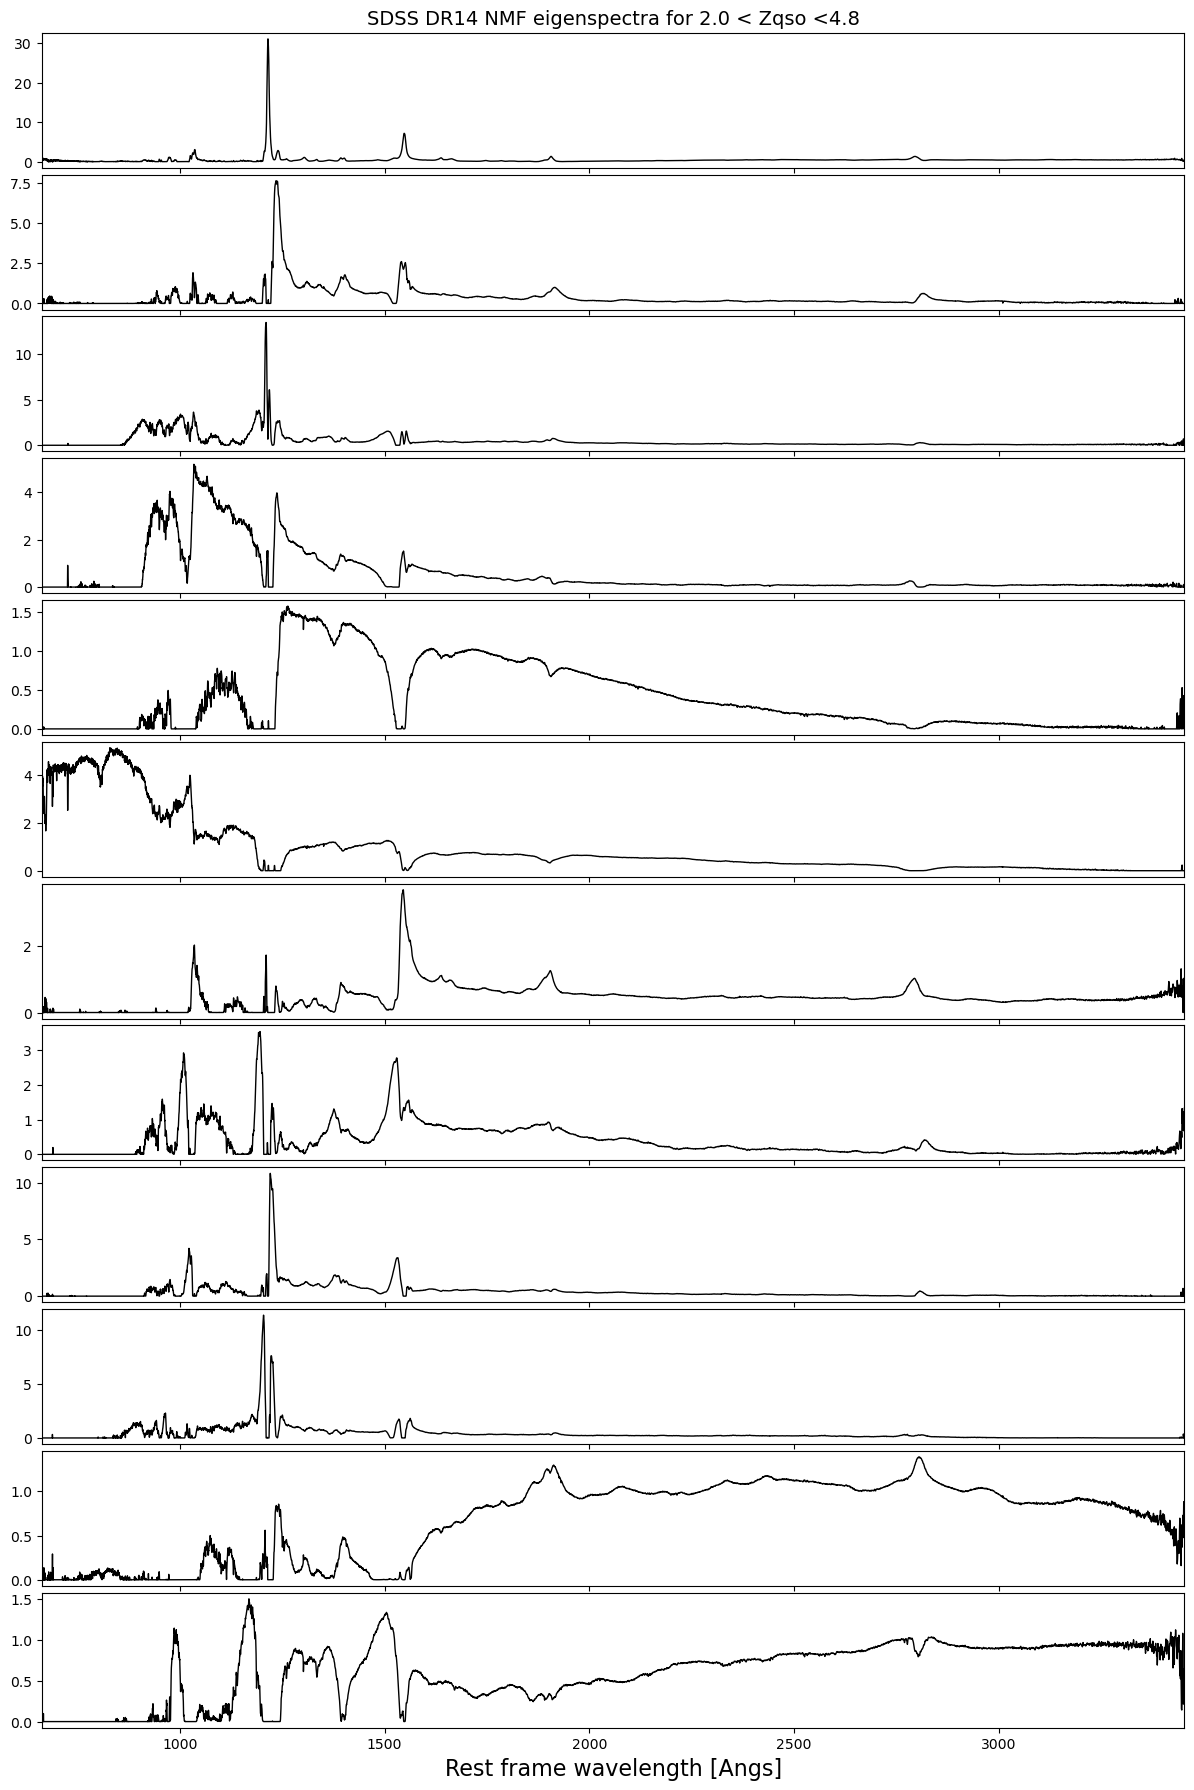

In [27]:
eigenspec_plotter(zmin=2, zmax=4.8)